In [1]:
import sys
import os
sys.path.insert(0, os.path.abspath(os.path.join('..')))

In [2]:
import numpy as np
import pandas as pd
from src.features import cycle
from src._xgboost import search_params_v5
from src.MultiVariateForecaster import MultiVariateForecaster
from skforecast.direct import ForecasterDirectMultiVariate
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
import joblib
import xgboost as xgb
import warnings
from skforecast.exceptions import IgnoredArgumentWarning

warnings.simplefilter('ignore', category=IgnoredArgumentWarning)

C:\Users\Ivan\AppData\Roaming\Python\Python312\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
def process_data(data: pd.DataFrame):
    df = data.copy()
    df = df.asfreq('D')
    
    df['day_of_year'] = df['Дата'].dt.dayofyear
    df = cycle(df, 'Месяц', 12)
    df = cycle(df, 'day_of_year', 365)
    
    df['is_anomaly'] = np.where(df['Дата'] <= '2021-05-01', 1, 0)
    
    df = df.drop(columns=['Дата'])
    
    df = df.interpolate(method='akima').ffill().bfill().round(2)
    
    return df

def plot_forecast(X_train, y_true, y_pred, title="Прогноз vs Истинные значения"):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))
    
    if not y_pred.index.equals(y_true.index):
        y_pred.index = y_true.index
    
    ax1.plot(y_true.index, y_true.values, label='Истинные', color='blue', linewidth=1.5)
    ax1.plot(y_pred.index, y_pred.values, label='Прогноз', color='red', linestyle='--', linewidth=1.5)
    ax1.set_xlabel('Дата')
    ax1.set_ylabel('Значение')
    ax1.set_title('Тестовый период')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    ax1.tick_params(axis='x', rotation=45)
    
    ax2.plot(X_train.index, X_train.values, 
             label='Исторические (X_train)', color='green', linewidth=1.5, alpha=0.7)
    ax2.plot(y_true.index, y_true.values, 
             label='Истинные (тест)', color='blue', linewidth=1.5)
    ax2.plot(y_pred.index, y_pred.values, 
             label='Прогноз', color='red', linestyle='--', linewidth=1.5)
    ax2.set_xlabel('Дата')
    ax2.set_ylabel('Значение')
    ax2.set_title('Полный период (история + тест)')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    ax2.tick_params(axis='x', rotation=45)
    
    fig.suptitle(title, fontsize=14, fontweight='bold')
    
    plt.tight_layout()
    plt.show()
    
def fit_best_model(df_train, best_params, target_cols, exog_cols):
    xgb_params = {
        'n_estimators': best_params['n_estimators'],
        'learning_rate': best_params['learning_rate'],
        'max_depth': best_params['max_depth'],
        'subsample': best_params['subsample'],
        'colsample_bytree': best_params['colsample_bytree'],
        'colsample_bylevel': best_params['colsample_bylevel'],
        'colsample_bynode': best_params['colsample_bynode'],
        'reg_alpha': best_params['reg_alpha'],
        'reg_lambda': best_params['reg_lambda'],
        'gamma': best_params['gamma'],
        'min_child_weight': best_params['min_child_weight'],
        'max_delta_step': best_params['max_delta_step'],
        'random_state': 42,
        'verbosity': 0,
        'n_jobs': -1
    }
    
    models = []
    for i in range(0, len(target_cols)):
        col = target_cols[i]
        lags_dict = {c: None for c in target_cols}
        lags_dict[col] = best_params[f'lags_{col}']
        if i != 0:
            neighbor_col = target_cols[i - 1]
            lags_dict[neighbor_col] = best_params[f'neighbor_lags_{col}_up']
        if i != len(target_cols) - 1:
            neighbor_col = target_cols[i + 1]
            lags_dict[neighbor_col] = best_params[f'neighbor_lags_{col}_down']
        models.append(ForecasterDirectMultiVariate(estimator=xgb.XGBRegressor(**xgb_params),
                                                level = col,
                                                steps = 1,
                                                lags = lags_dict))       
        
    forecaster = MultiVariateForecaster(models)
    forecaster.fit(df_train[target_cols], exog=df_train[exog_cols])
    
    return forecaster

In [4]:
df_train_full = pd.read_csv('../data/processed/train_raw, ZK 68, (48-1, 48-air), 27.11.20-31.12.24.csv', parse_dates=['Дата'])
df_train_full.index = df_train_full['Дата']

df_test = pd.read_csv('../data/processed/test_raw, ZK 68, (48-1, 48-air), 01.01.25-15.12.25.csv', parse_dates=['Дата'])
df_test.index = df_test['Дата']

df_train = df_train_full[:'2023-12-31'].copy()
df_val = df_train_full['2024-01-01':].copy()

In [5]:
df_train_full = process_data(df_train_full)
df_train = process_data(df_train)
df_val = process_data(df_val)
df_test = process_data(df_test)

In [6]:
model_path = f'../xgboost/models/xgb_v6'
target_cols = ['48-1 (0)','48-1 (1)','48-1 (2)', '48-1 (3)', '48-1 (4)', '48-1 (5)', '48-1 (6)', '48-1 (7)', '48-1 (8)', '48-1 (9)', '48-1 (10)']
exog_cols = ['Месяц_sin', 'Месяц_cos', 'day_of_year_sin', 'day_of_year_cos', 'is_anomaly']

In [25]:
study = search_params_v5(df_train, df_val, target_cols, exog_cols=exog_cols, n_trials=10)
best_params = study.best_params
print(f'Лучшие параметры = {best_params}')
print(f'Лучший RMSE score = {study.best_value}')

[I 2026-05-21 20:06:39,623] A new study created in memory with name: no-name-3c03071b-50a5-4d48-a9f9-e3836a7c80b3
[I 2026-05-21 20:06:52,720] Trial 0 finished with value: 0.31211594823877553 and parameters: {'n_estimators': 364, 'learning_rate': 0.01680356267762767, 'max_depth': 5, 'subsample': 0.47708161295795437, 'colsample_bytree': 0.7546282969677626, 'colsample_bylevel': 0.6113987935461389, 'colsample_bynode': 0.5563860274016481, 'reg_alpha': 0.003794583788630498, 'reg_lambda': 0.0001080695601638068, 'gamma': 0.03591121060540008, 'min_child_weight': 11, 'max_delta_step': 8, 'lags_48-1 (0)': 2, 'neighbor_lags_48-1 (0)_down': 3, 'lags_48-1 (1)': 1, 'neighbor_lags_48-1 (1)_up': 3, 'neighbor_lags_48-1 (1)_down': 2, 'lags_48-1 (2)': 4, 'neighbor_lags_48-1 (2)_up': 3, 'neighbor_lags_48-1 (2)_down': 3, 'lags_48-1 (3)': 1, 'neighbor_lags_48-1 (3)_up': 3, 'neighbor_lags_48-1 (3)_down': 1, 'lags_48-1 (4)': 4, 'neighbor_lags_48-1 (4)_up': 2, 'neighbor_lags_48-1 (4)_down': 1, 'lags_48-1 (5)': 

Лучшие параметры = {'n_estimators': 364, 'learning_rate': 0.01680356267762767, 'max_depth': 5, 'subsample': 0.47708161295795437, 'colsample_bytree': 0.7546282969677626, 'colsample_bylevel': 0.6113987935461389, 'colsample_bynode': 0.5563860274016481, 'reg_alpha': 0.003794583788630498, 'reg_lambda': 0.0001080695601638068, 'gamma': 0.03591121060540008, 'min_child_weight': 11, 'max_delta_step': 8, 'lags_48-1 (0)': 2, 'neighbor_lags_48-1 (0)_down': 3, 'lags_48-1 (1)': 1, 'neighbor_lags_48-1 (1)_up': 3, 'neighbor_lags_48-1 (1)_down': 2, 'lags_48-1 (2)': 4, 'neighbor_lags_48-1 (2)_up': 3, 'neighbor_lags_48-1 (2)_down': 3, 'lags_48-1 (3)': 1, 'neighbor_lags_48-1 (3)_up': 3, 'neighbor_lags_48-1 (3)_down': 1, 'lags_48-1 (4)': 4, 'neighbor_lags_48-1 (4)_up': 2, 'neighbor_lags_48-1 (4)_down': 1, 'lags_48-1 (5)': 4, 'neighbor_lags_48-1 (5)_up': 2, 'neighbor_lags_48-1 (5)_down': 1, 'lags_48-1 (6)': 5, 'neighbor_lags_48-1 (6)_up': 3, 'neighbor_lags_48-1 (6)_down': 3, 'lags_48-1 (7)': 3, 'neighbor_lag

In [26]:
model = fit_best_model(df_train, best_params, target_cols, exog_cols)
joblib.dump(model, model_path)

['../xgboost/models/xgb_v6']

48-1 (0)
RMSE на тесте = 2.673624241528628


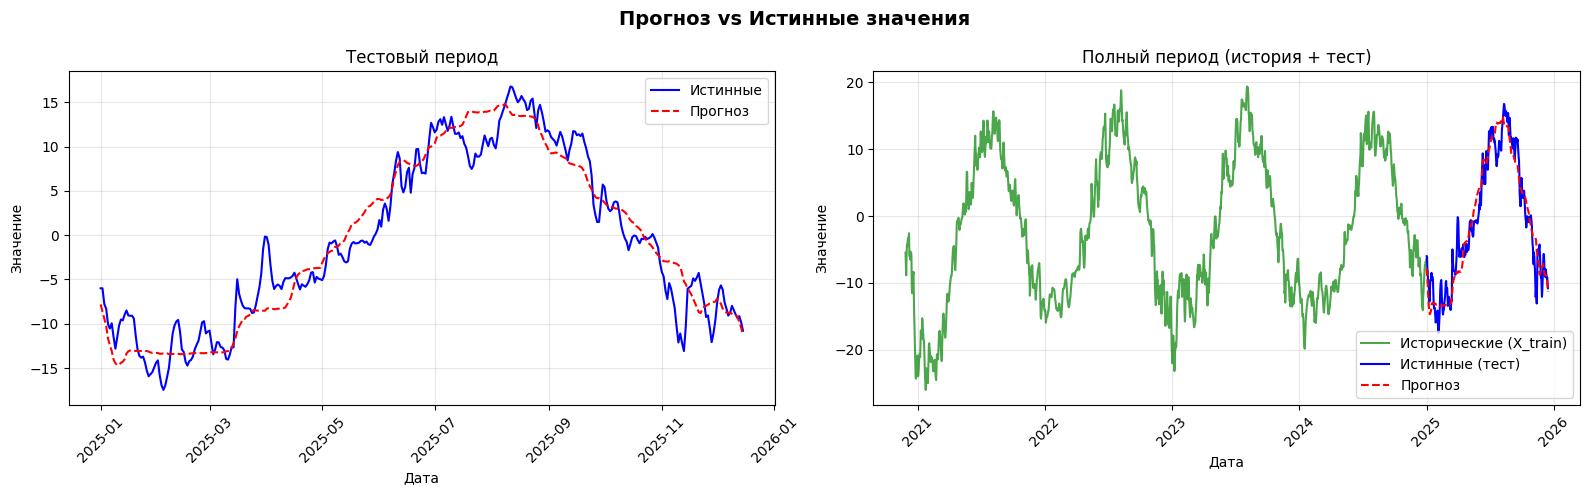

           feature  importance
6        Месяц_cos    0.271359
8  day_of_year_cos    0.137342
1   48-1 (0)_lag_2    0.122992
9       is_anomaly    0.109227
3   48-1 (1)_lag_2    0.097869
0   48-1 (0)_lag_1    0.079984
2   48-1 (1)_lag_1    0.072854
5        Месяц_sin    0.040254
4   48-1 (1)_lag_3    0.038642
7  day_of_year_sin    0.029478
48-1 (1)
RMSE на тесте = 1.37171786100129


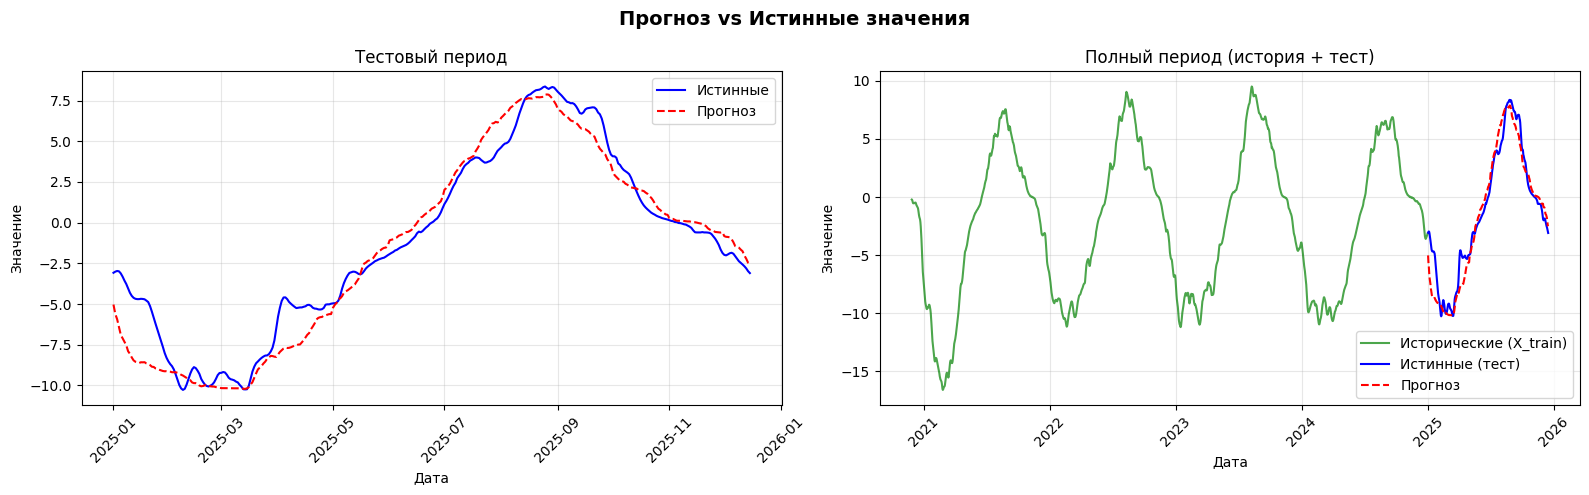

            feature  importance
1    48-1 (0)_lag_2    0.172800
7         Месяц_cos    0.163373
2    48-1 (0)_lag_3    0.112932
8   day_of_year_sin    0.092444
6         Месяц_sin    0.087214
5    48-1 (2)_lag_2    0.079330
0    48-1 (0)_lag_1    0.075037
4    48-1 (2)_lag_1    0.074290
3    48-1 (1)_lag_1    0.064182
10       is_anomaly    0.040673
9   day_of_year_cos    0.037726
48-1 (2)
RMSE на тесте = 0.9199020305493335


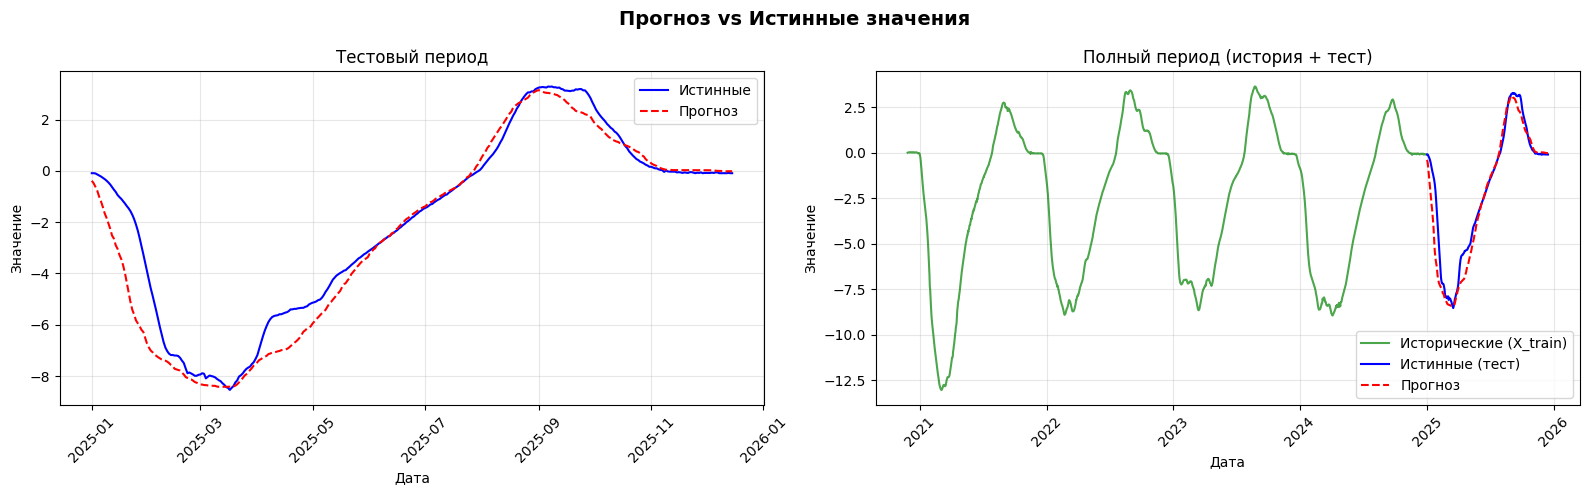

            feature  importance
8    48-1 (3)_lag_2    0.140536
12  day_of_year_sin    0.137362
6    48-1 (2)_lag_4    0.122959
7    48-1 (3)_lag_1    0.113586
10        Месяц_sin    0.080579
5    48-1 (2)_lag_3    0.078017
14       is_anomaly    0.072871
3    48-1 (2)_lag_1    0.057460
9    48-1 (3)_lag_3    0.056706
4    48-1 (2)_lag_2    0.052861
2    48-1 (1)_lag_3    0.034214
11        Месяц_cos    0.018326
1    48-1 (1)_lag_2    0.015073
0    48-1 (1)_lag_1    0.011646
13  day_of_year_cos    0.007805
48-1 (3)
RMSE на тесте = 0.6661649494367089


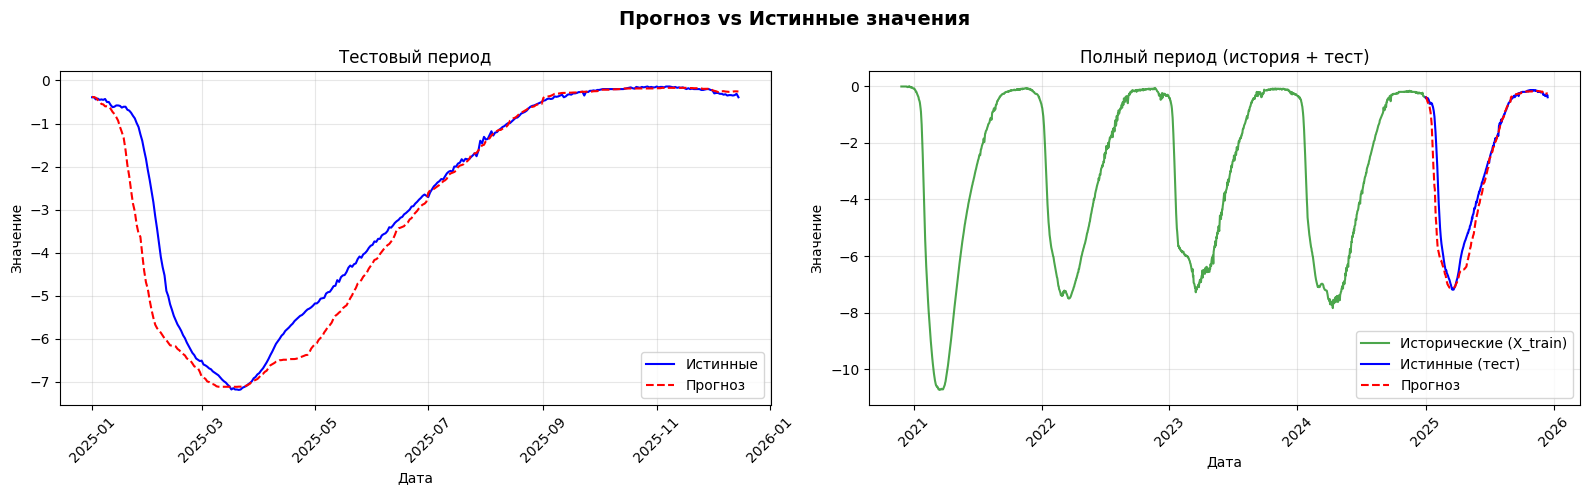

           feature  importance
7  day_of_year_sin    0.202082
4   48-1 (4)_lag_1    0.140403
2   48-1 (2)_lag_3    0.131995
0   48-1 (2)_lag_1    0.124858
5        Месяц_sin    0.123687
3   48-1 (3)_lag_1    0.112819
1   48-1 (2)_lag_2    0.093239
9       is_anomaly    0.033905
8  day_of_year_cos    0.023840
6        Месяц_cos    0.013173
48-1 (4)
RMSE на тесте = 0.506164897614422


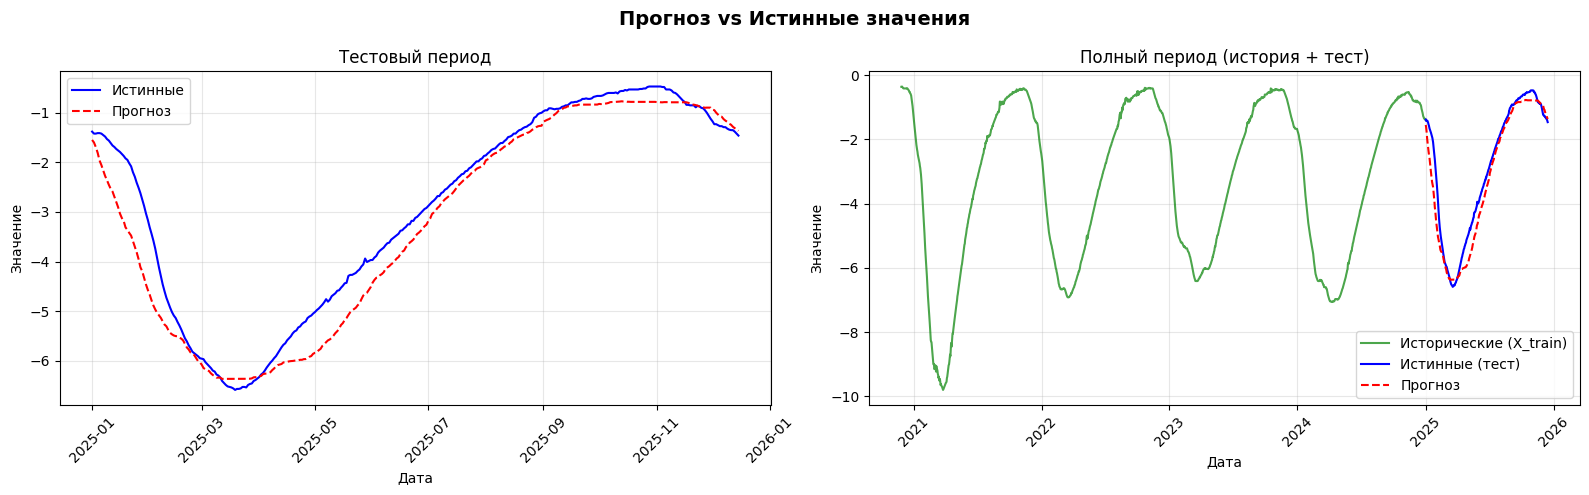

            feature  importance
7         Месяц_sin    0.232258
4    48-1 (4)_lag_3    0.130879
3    48-1 (4)_lag_2    0.129582
9   day_of_year_sin    0.094215
6    48-1 (5)_lag_1    0.091355
0    48-1 (3)_lag_1    0.073368
2    48-1 (4)_lag_1    0.070608
1    48-1 (3)_lag_2    0.059901
5    48-1 (4)_lag_4    0.054330
11       is_anomaly    0.044684
8         Месяц_cos    0.009823
10  day_of_year_cos    0.008997
48-1 (5)
RMSE на тесте = 0.49332359672060877


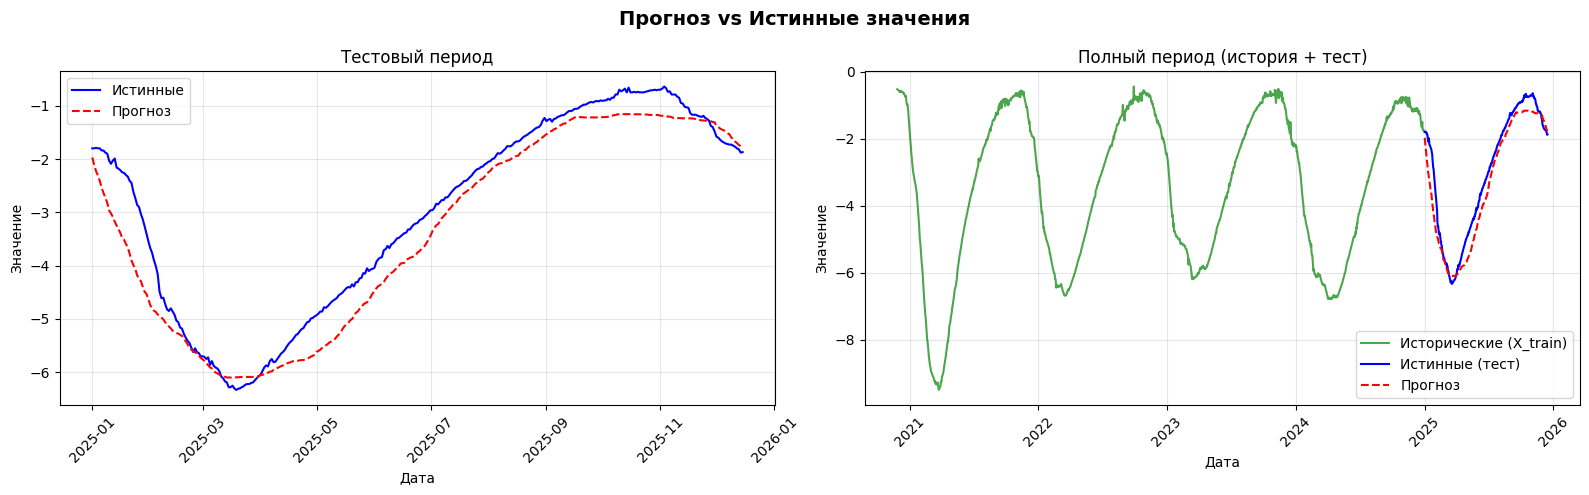

            feature  importance
4    48-1 (5)_lag_3    0.168689
5    48-1 (5)_lag_4    0.142129
6    48-1 (6)_lag_1    0.124261
9   day_of_year_sin    0.100272
1    48-1 (4)_lag_2    0.090633
7         Месяц_sin    0.088895
0    48-1 (4)_lag_1    0.085322
2    48-1 (5)_lag_1    0.057466
3    48-1 (5)_lag_2    0.054964
11       is_anomaly    0.052933
8         Месяц_cos    0.018275
10  day_of_year_cos    0.016160
48-1 (6)
RMSE на тесте = 0.47239474450545255


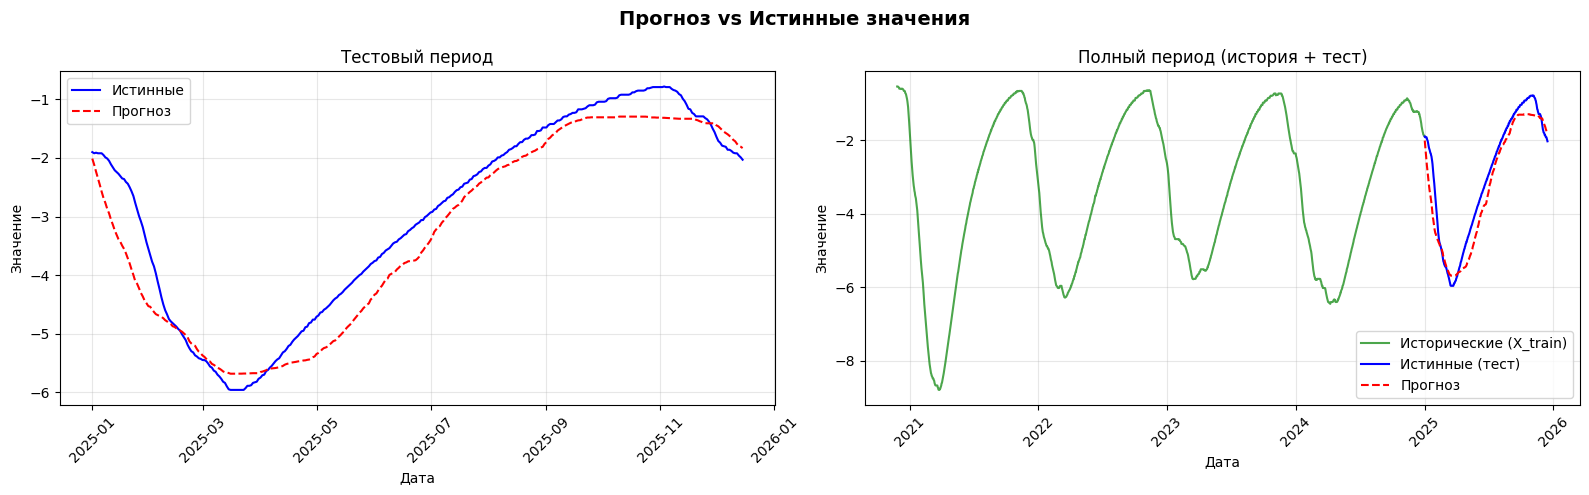

            feature  importance
7    48-1 (6)_lag_5    0.176087
10   48-1 (7)_lag_3    0.145677
6    48-1 (6)_lag_4    0.087079
11        Месяц_sin    0.082418
8    48-1 (7)_lag_1    0.073386
9    48-1 (7)_lag_2    0.069282
3    48-1 (6)_lag_1    0.066697
4    48-1 (6)_lag_2    0.059808
1    48-1 (5)_lag_2    0.054393
5    48-1 (6)_lag_3    0.053481
0    48-1 (5)_lag_1    0.051777
2    48-1 (5)_lag_3    0.039833
13  day_of_year_sin    0.026613
15       is_anomaly    0.011701
14  day_of_year_cos    0.000894
12        Месяц_cos    0.000876
48-1 (7)
RMSE на тесте = 0.43902353534625094


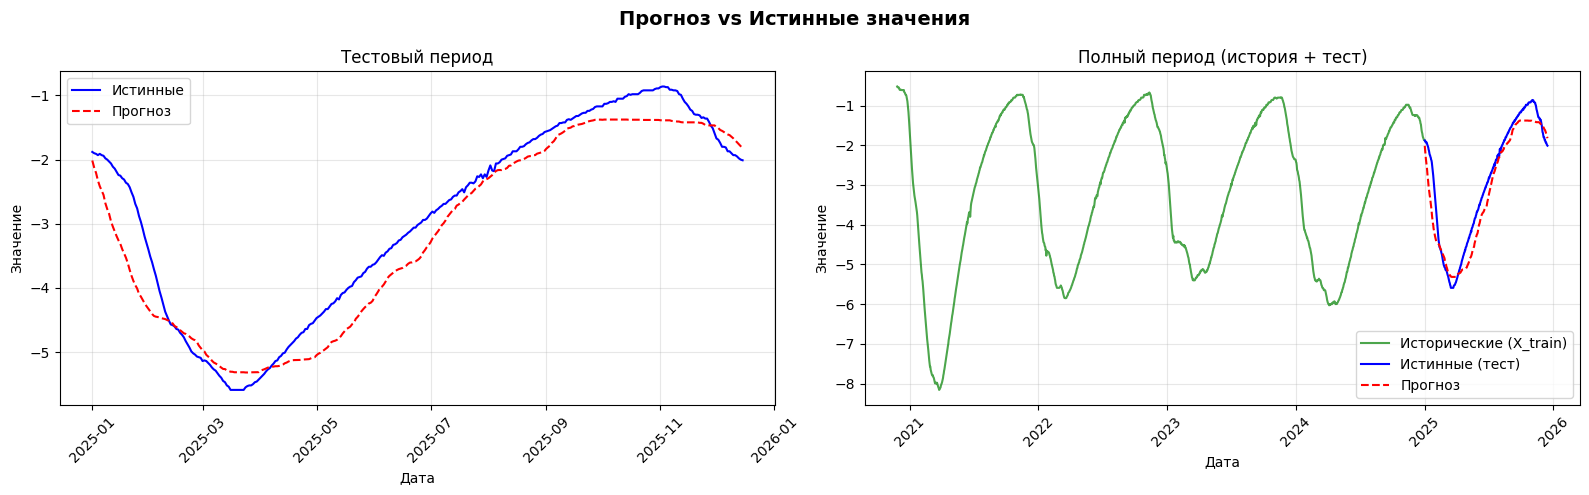

            feature  importance
8         Месяц_sin    0.147738
5    48-1 (7)_lag_3    0.142833
7    48-1 (8)_lag_2    0.115394
1    48-1 (6)_lag_2    0.090290
2    48-1 (6)_lag_3    0.081106
12       is_anomaly    0.080065
3    48-1 (7)_lag_1    0.079561
6    48-1 (8)_lag_1    0.071548
4    48-1 (7)_lag_2    0.067691
10  day_of_year_sin    0.060132
0    48-1 (6)_lag_1    0.053192
11  day_of_year_cos    0.007091
9         Месяц_cos    0.003358
48-1 (8)
RMSE на тесте = 0.3780757862389571


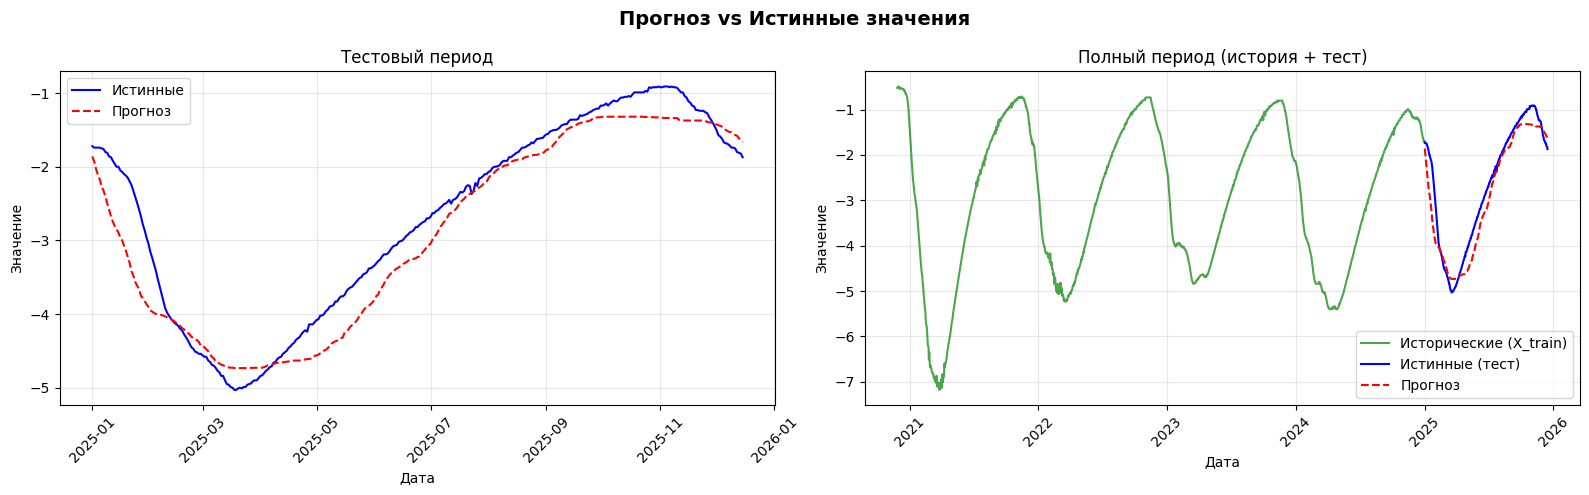

            feature  importance
5    48-1 (9)_lag_1    0.136926
8   day_of_year_sin    0.131548
0    48-1 (7)_lag_1    0.124599
4    48-1 (8)_lag_3    0.124291
1    48-1 (7)_lag_2    0.117689
2    48-1 (8)_lag_1    0.112091
3    48-1 (8)_lag_2    0.097442
6         Месяц_sin    0.091425
10       is_anomaly    0.038843
9   day_of_year_cos    0.013816
7         Месяц_cos    0.011332
48-1 (9)
RMSE на тесте = 0.2670730695866057


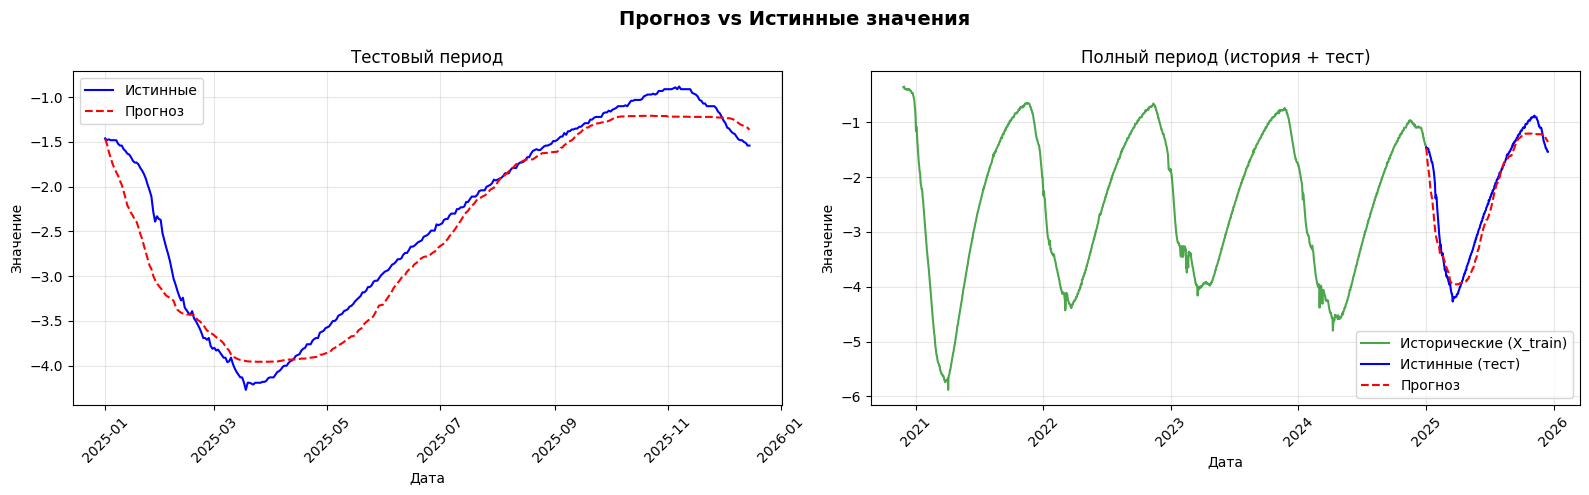

            feature  importance
9         Месяц_sin    0.141367
7   48-1 (10)_lag_2    0.108598
6   48-1 (10)_lag_1    0.100458
0    48-1 (8)_lag_1    0.091712
4    48-1 (9)_lag_3    0.083499
3    48-1 (9)_lag_2    0.081999
5    48-1 (9)_lag_4    0.077614
2    48-1 (9)_lag_1    0.075593
1    48-1 (8)_lag_2    0.075014
11  day_of_year_sin    0.053351
13       is_anomaly    0.048895
8   48-1 (10)_lag_3    0.046528
12  day_of_year_cos    0.010926
10        Месяц_cos    0.004447
48-1 (10)
RMSE на тесте = 0.16245897779086482


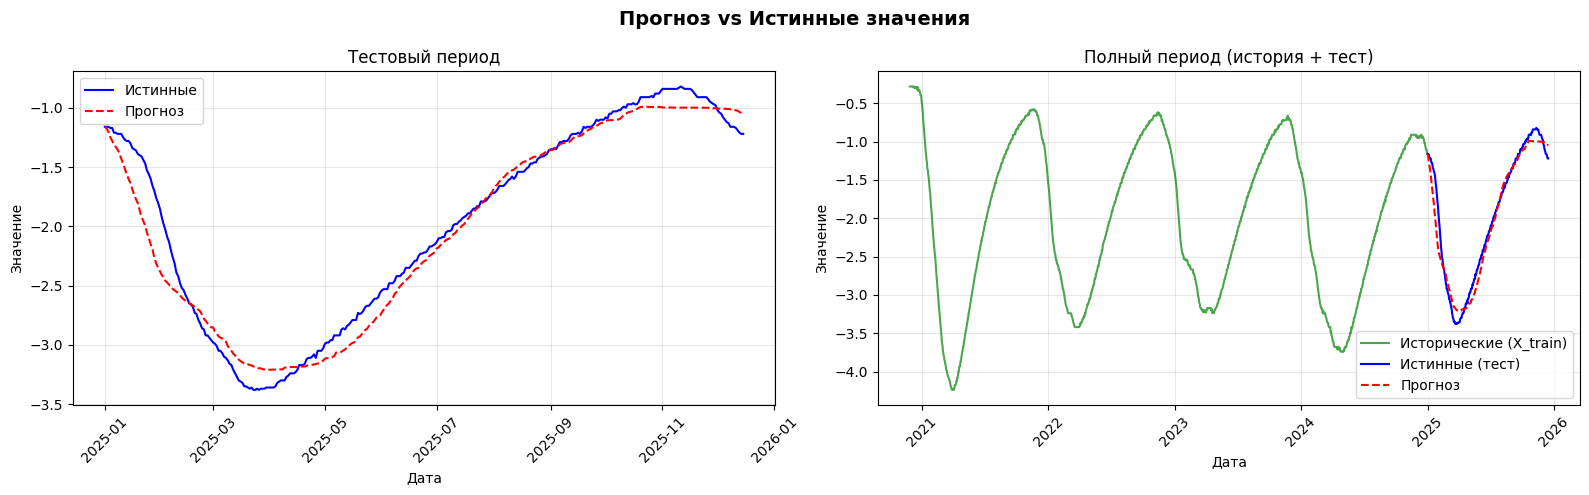

            feature  importance
6         Месяц_sin    0.234156
4   48-1 (10)_lag_4    0.157962
1   48-1 (10)_lag_1    0.127196
8   day_of_year_sin    0.105453
0    48-1 (9)_lag_1    0.094660
3   48-1 (10)_lag_3    0.086320
2   48-1 (10)_lag_2    0.085332
5   48-1 (10)_lag_5    0.046939
10       is_anomaly    0.024639
7         Месяц_cos    0.021951
9   day_of_year_cos    0.015393


In [27]:
model = joblib.load(model_path)
predicts = model.predict(len(df_test), df_train_full[target_cols], exog=df_test[exog_cols])
for col in target_cols:
    print(col)
    y_pred = predicts[col]
    y_true = df_test[col]
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    print(f'RMSE на тесте = {rmse}')
    
    plot_forecast(df_train_full[col], y_true, y_pred)
    
    importances = model.forecasters[col].get_feature_importances(step = 1)
    print(importances)